# ISSM "square ice shelf" tutorial (with transient solution): ```issm_helper``` version

This script reproduces ISSM's square ice shelf tutorial, using ```issm_helper``` to streamline the workflow. 

## Imports

In [1]:
########################
### "normal" imports ###
########################

import numpy as np
import matplotlib.pyplot as plt

######################
### ISSM functions ###
######################

from issm_helper import * #almost all necessariy ISSM functionality is in here
from model import model
from squaremesh import squaremesh

## Initialize model and mesh domain

In [2]:
lx, ly, nx, ny = 1.2e6, 1e6, 40, 40 #length in x and y, number of nodes in x and y

md = model()
md = squaremesh(md, lx, ly, nx, ny) #squaremesh(model, x, y, nx, ny)

## Describe boundaries and levelsets

ISSM needs to know which parts of the domain are grounded ice, floating ice, terminus boundary, and ocean. Additionally, it will be useful to set up distinct boundary subsets (terminus, sidewalls, and inflow boundary). 

In [3]:
x, y = md.mesh.x, md.mesh.y
x_max, x_min, y_max, y_min = x.max(), x.min(), y.max(), y.min()
x_t = 1e6 #unlike the tutorial, we'll have the shelf terminate before the end of the domain

########################################
### describe the boundary components ###
########################################

Γ_terminus = np.isclose(x, x_t, atol = 1e-10) #choose the terminus to lie on the rightmost boundary
Γ_inflow = (x == x_min) #inflow boundary on the leftmost boundary
Γ_sidewalls = (y == y_max) | (y == y_min) #sidewalls on the upper and lower boundaries

##############################
### describe the levelsets ###
##############################

md.mask.ice_levelset = x - x_t   # ice < 0, no-ice > 0, terminus = 0
waterline = 0 #ocean levelset will be determined from this alone

## Material parameters and initialization

In [4]:
##########################
### material densities ###
##########################

ρ_i = md.materials.rho_ice
ρ_w = md.materials.rho_water
ϱ = ρ_i/ρ_w

########################
### initial geometry ###
########################

H_min = 300
H_max = 1000
H = H_max + (H_min - H_max)*(x - x_min)/(x_t - x_min) #initial thickness increases linearly from H_min at the terminus

In [5]:
initialize_model(md, temperature = 253.15, approximation = 'SSA',  
                 dirichlet_x = Γ_inflow | Γ_sidewalls, dirichlet_y = Γ_inflow | Γ_sidewalls, dirichlet_H = Γ_inflow,
                 waterline = waterline)

      no smb.mass_balance specified: values set as zero


## Get the instantaneous solution (no timestepping)

In [6]:
u = diagnostic_solve(md, thickness = H, velocity = (0, 0))

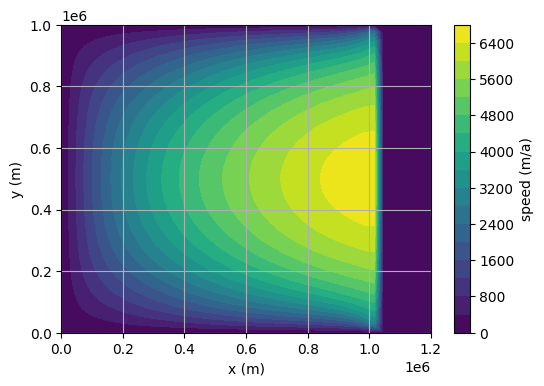

In [7]:
elts = md.mesh.elements - 1
speed_steady = np.hypot(u[0], u[1])

plt.figure(figsize = (6, 4))
plt.tricontourf(x, y, elts, speed_steady, levels = 20)
plt.colorbar(label = 'speed (m/a)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.gca().set_aspect('equal')
plt.grid()
plt.show()

## Choose parameters for transient solution

Do this for a non-moving front (i.e., we assume that the advance rate is exactly counteracted by some form of frontal ablation). 

In [8]:
Δt = 2
model_time = 100
num_timesteps = int(model_time/Δt)

import tqdm
for step in tqdm.trange(num_timesteps):
    u, H, s = coupled_solve(md, Δt, velocity = u, thickness = H, thickness_inflow = H_max, stabilization = 1)               

100%|██████████| 50/50 [01:11<00:00,  1.44s/it]


## And solve

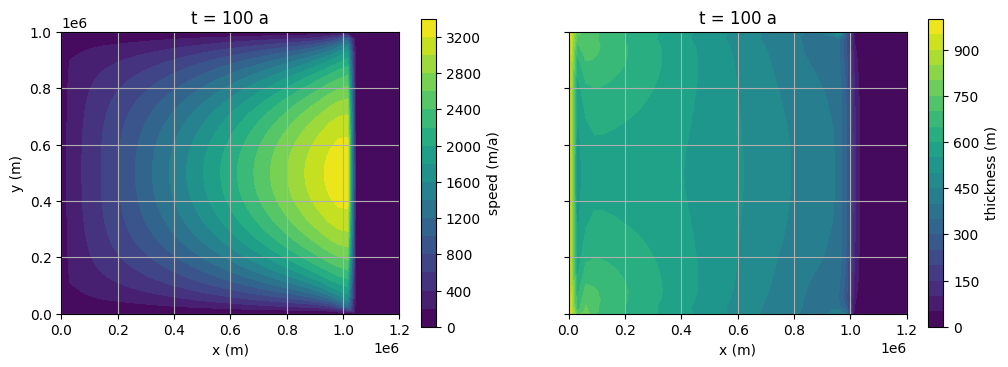

In [9]:
ΔH = H - H_max
vmax = np.max(np.abs(ΔH))
speed = np.hypot(u[0], u[1])

fig, ax = plt.subplots(1, 2, figsize = (12, 4), sharex = True, sharey = True)

c0 = ax[0].tricontourf(x, y, elts, speed, levels = 20)
fig.colorbar(c0, ax = ax[0], label = 'speed (m/a)')
ax[0].set_title(f't = {model_time:g} a')
ax[0].set_xlabel('x (m)')
ax[0].set_ylabel('y (m)')
ax[0].set_aspect('equal')
ax[0].set_ylim(np.min(y), np.max(y))
ax[0].grid()

c1 = ax[1].tricontourf(x, y, elts, H, levels = 20)
fig.colorbar(c1, ax = ax[1], label = 'thickness (m)')
ax[1].set_title(f't = {model_time:g} a')
ax[1].set_xlabel('x (m)')
ax[1].set_aspect('equal')
ax[1].grid()

plt.show()